<a href="https://colab.research.google.com/github/vasilisazhuk/DigitalSignalProcessing/blob/main/LAB_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt

In [ ]:
#Константы
FREQ_CAR = 845                  #Несущая частота
FREQ_MOD = 31                   #Модулируемая частота
QUAN_LV = 128                   #Число уровней квантования
TIME_END = 0.5                  #Время моделирования
PHASE_MOD = 0                   #Фаза моделируемой частоты
PHASE_CAR = 0                   #Фаза несущей частоты
M = 1                           #Коэффициент модуляции
K_DISC = 8
SAMPLE_RATE = FREQ_CAR * K_DISC #Частота дискретизации
SAMPLE_PER = 1/SAMPLE_RATE      #Период дискретизации


In [ ]:
t = np.arange(0, TIME_END, SAMPLE_PER)
N = len(t)
signal = 0.5 * (1 + M * np.sin(2 * np.pi * FREQ_MOD * t + PHASE_MOD)) * np.sin(2 * np.pi * t * FREQ_CAR + PHASE_CAR)
disc_mod_sig = np.floor((signal + M) * QUAN_LV / (2*M))

/tmp/ipython-input-3502200227.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


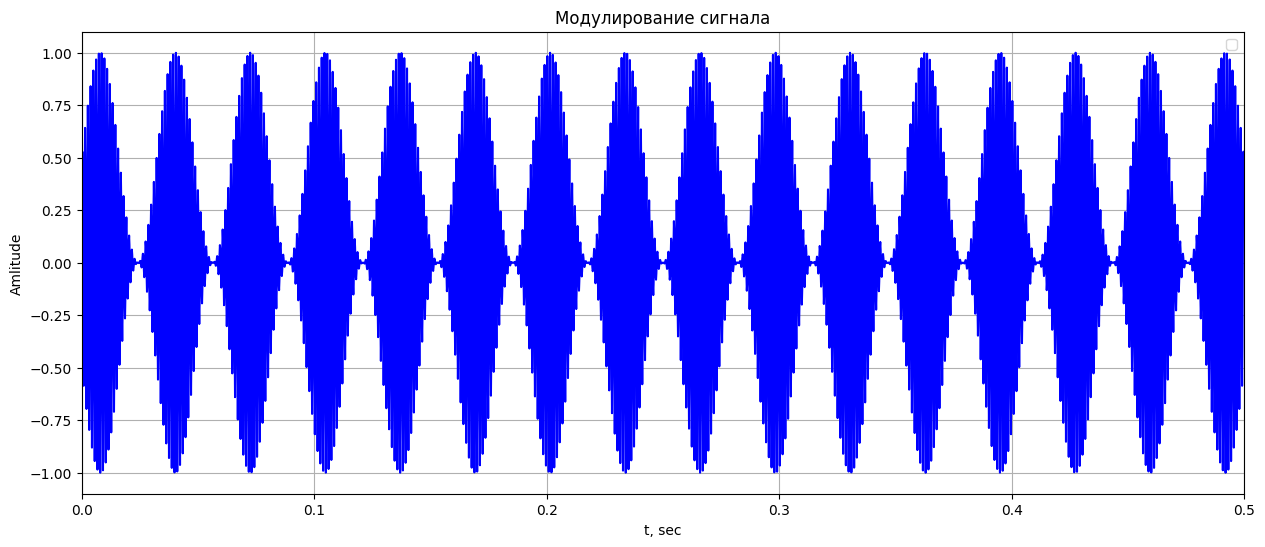

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, signal, color='blue')
plt.title("Модулирование сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#АЦП преобразование
y = np.floor((signal + M) * QUAN_LV/(2*M))

/tmp/ipython-input-96874336.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


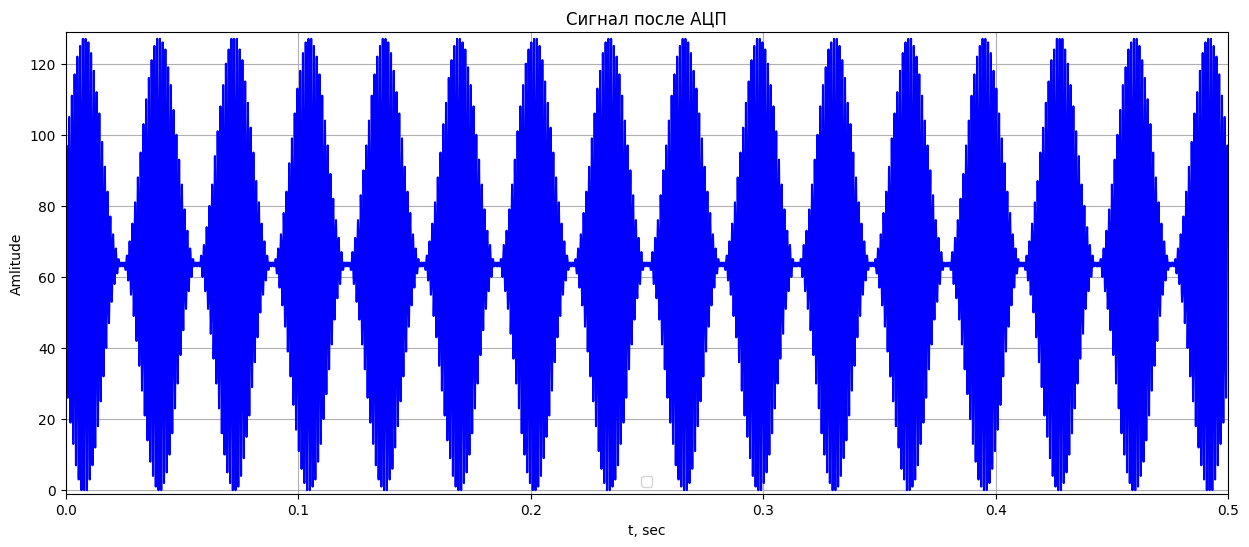

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, y, color='blue')
plt.title("Сигнал после АЦП")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1, QUAN_LV + 1])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Перенос частоты
sin_out = np.zeros(N)
cos_out = np.zeros(N)
for i in range(N):
  sin_out[i] = y[i]* np.sin(i *2 *np.pi * FREQ_CAR/SAMPLE_RATE)
  cos_out[i] = y[i]* np.cos(i*2*np.pi*FREQ_CAR/SAMPLE_RATE)

#Применение фильтра
b,a = sci.signal.butter(2, FREQ_MOD * K_DISC /(2*SAMPLE_RATE))
sin_out_butt = sci.signal.lfilter(b, a, sin_out)
cos_out_butt = sci.signal.lfilter(b, a, cos_out)

#Детектирование
detection = np.sqrt(sin_out_butt **2 + cos_out_butt **2)

/tmp/ipython-input-3520338887.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


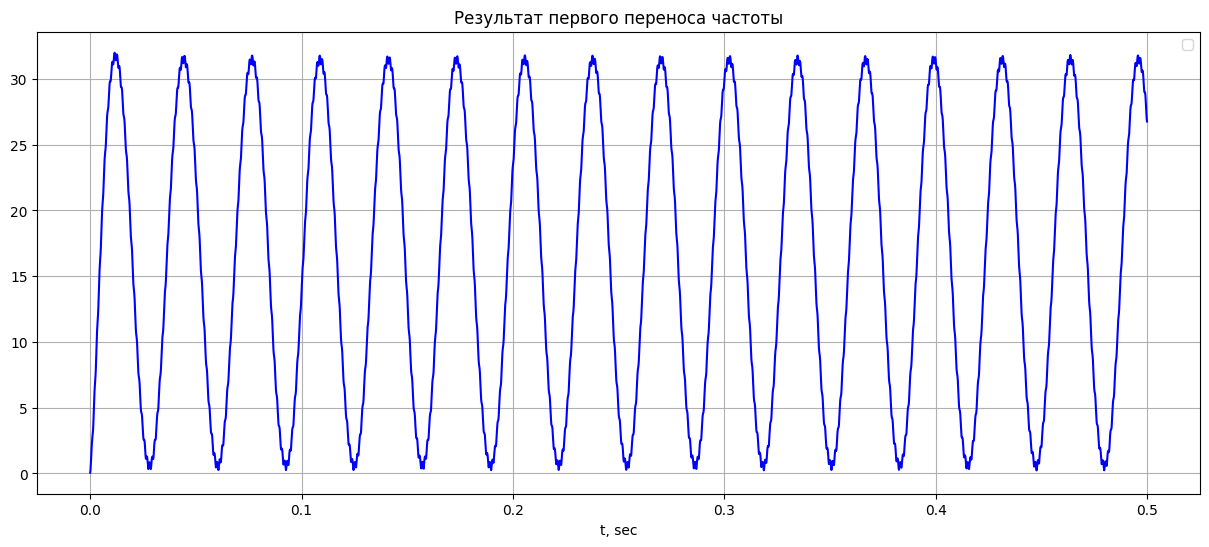

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection, color='blue')
plt.title("Результат первого переноса частоты")
plt.xlabel("t, sec")
#plt.ylabel("Amlitude")
#plt.axis([0, TIME_END, -1, QUAN_LV + 1])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Второй перенос частоты
sin_out2 = np.zeros(N)
cos_out2 = np.zeros(N)

for i in range(N):
    sin_out2[i] = detection[i] * np.sin(i * 2 * np.pi * FREQ_MOD / SAMPLE_RATE)
    cos_out2[i] = detection[i] * np.cos(i * 2 * np.pi * FREQ_MOD / SAMPLE_RATE)

# Применение фильтра Баттерворта 2-го порядка
b2, a2 = sci.signal.butter(2, FREQ_MOD * K_DISC / (2 * 8 *  SAMPLE_RATE))
sin_out2_butt = sci.signal.lfilter(b2, a2, sin_out2)
cos_out2_butt = sci.signal.lfilter(b2, a2, cos_out2)

detection2 = np.sqrt(sin_out2_butt ** 2 + cos_out2_butt ** 2)


In [ ]:
# Четвертый перенос частоты
b4, a4 = sci.signal.butter(4, (FREQ_MOD * K_DISC / (2 * 8 * SAMPLE_RATE)))
sin_out4_butt4 = sci.signal.lfilter(b4, a4, sin_out2)
cos_out4_butt4 = sci.signal.lfilter(b4, a4, cos_out2)
detection4 = np.sqrt(sin_out4_butt4 ** 2 + cos_out4_butt4 ** 2)

In [ ]:
# Шестой перенос частоты
b6, a6 = sci.signal.butter(6, (FREQ_MOD * K_DISC / (2 * 8 * SAMPLE_RATE)))
sin_out6_butt6 = sci.signal.lfilter(b6, a6, sin_out2)
cos_out6_butt6 = sci.signal.lfilter(b6, a6, cos_out2)
detection6 = np.sqrt(sin_out6_butt6 ** 2 + cos_out6_butt6 ** 2)

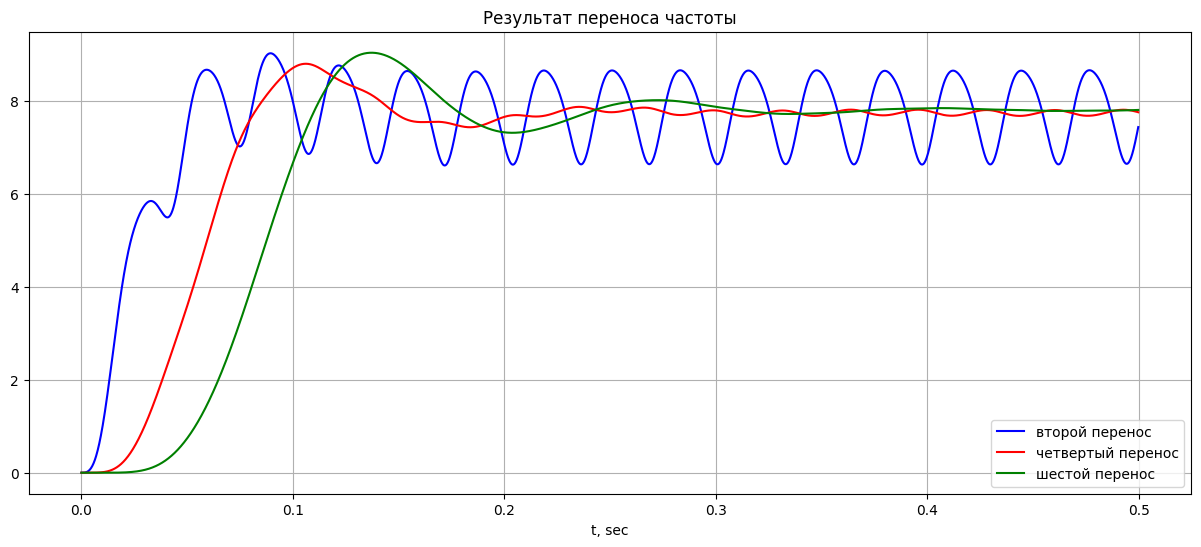

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection2, color='blue', label='второй перенос')
plt.plot(t, detection4, color='red', label='четвертый перенос')
plt.plot(t, detection6, color='green', label='шестой перенос')
plt.title("Результат переноса частоты")
plt.xlabel("t, sec")
#plt.ylabel("Amlitude")
#plt.axis([0, TIME_END, -1, QUAN_LV + 1])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
cnt = len(t)/4
mid2 = sum(detection2[int(cnt):2*int(cnt)])
mid4 = sum(detection4[int(cnt):2*int(cnt)])
mid6 = sum(detection6[int(cnt):2*int(cnt)])

mid2 = mid2 / cnt * 0.708
mid4 = mid4 / cnt * 0.708
mid6 = mid6 / cnt * 0.708

print(mid2, mid4, mid6)

5.485880387317849 5.473304950370664 5.6576433054984605


In [ ]:
#Определение наличия сигнала
lbound = mid2
sig_out2 = [1] * N
for k in range(N):
    if detection2[k] <= lbound:
        sig_out2[k] = 0
    else:
        break

lbound = mid4
sig_out4 = [1] * N
for k in range(N):
    if detection4[k] <= lbound:
        sig_out4[k] = 0
    else:
        break

lbound = mid6
sig_out6 = [1] * N
for k in range(N):
    if detection6[k] <= lbound:
        sig_out6[k] = 0
    else:
        break

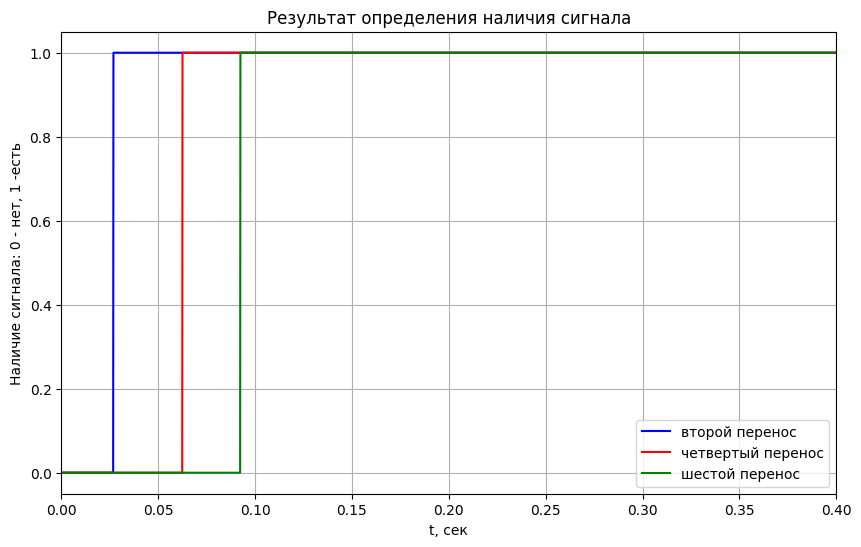

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, sig_out2, color='blue', label='второй перенос')
plt.plot(t, sig_out4, color='red', label='четвертый перенос')
plt.plot(t, sig_out6, color='green', label='шестой перенос')
plt.title("Результат определения наличия сигнала")
plt.xlabel("t, сек")
plt.ylabel("Наличие сигнала: 0 - нет, 1 -есть")
plt.xlim([0, 0.4])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
k = 1
while sig_out2[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

k = 1
while sig_out4[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

k = 1
while sig_out6[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

Задержка составляет:  0.026923076923076925
Задержка составляет:  0.06257396449704142
Задержка составляет:  0.09245562130177515


In [ ]:
FREQ_CAR_NOISE =938
PHASE_CAR_NOISE = 0

mod_sig_noise = signal + 0.5*np.sin(2*np.pi*FREQ_CAR_NOISE*t+PHASE_CAR_NOISE)

/tmp/ipython-input-848602873.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


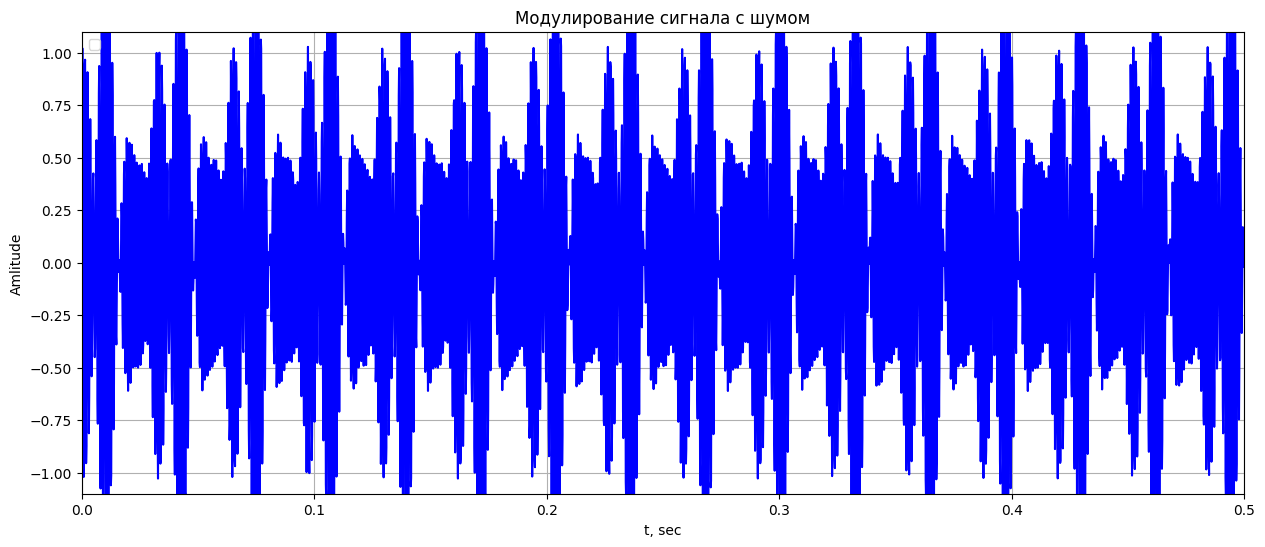

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, mod_sig_noise, color='blue')
plt.title("Модулирование сигнала с шумом")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, TIME_END, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
fftL = 2 ** np.ceil(np.log2(N)).astype(int)
Y = np.fft.fft(signal, fftL)
Y_magnitude = np.abs(Y[:fftL // 2])
Y_magnitude = 2 * Y_magnitude / N
F = np.linspace(0, SAMPLE_RATE/2, fftL // 2)

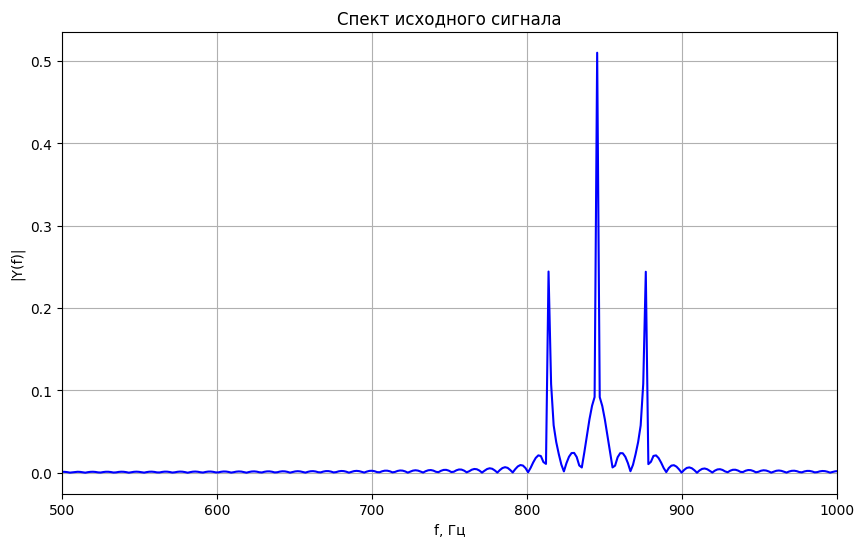

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(F, Y_magnitude, color='blue')
plt.title("Спект исходного сигнала")
plt.xlabel("f, Гц")
plt.ylabel("|Y(f)|")
plt.grid(True)
plt.xlim(500, 1000)
plt.show()

In [ ]:
Y_noise = np.fft.fft(mod_sig_noise, fftL)
Y_magnitude_noise = np.abs(Y_noise[:fftL // 2])
Y_magnitude_noise = 2 * Y_magnitude_noise / N
#F = np.linspace(0, SAMPLE_RATE/2, fftL // 2)

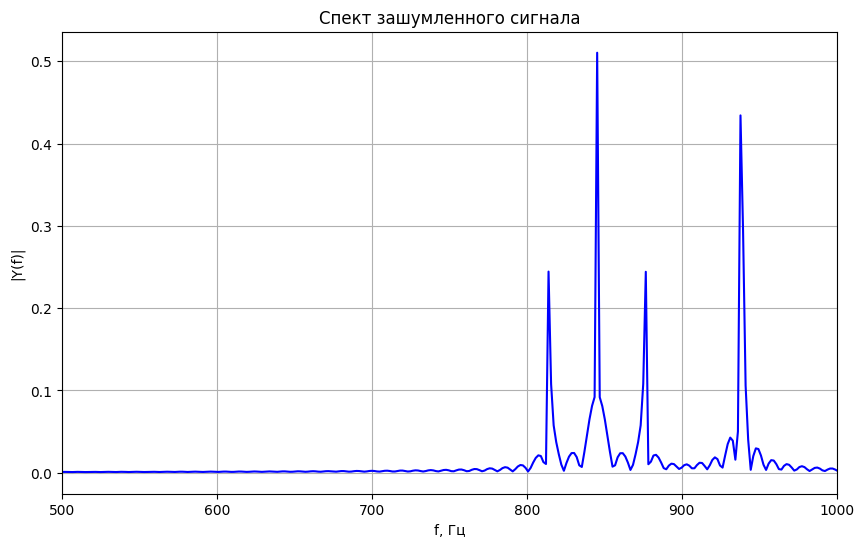

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(F, Y_magnitude_noise, color='blue')
plt.title("Спект зашумленного сигнала")
plt.xlabel("f, Гц")
plt.ylabel("|Y(f)|")
plt.grid(True)
plt.xlim(500, 1000)
plt.show()


In [ ]:
# Алгоритм "плавающего" порога
L = 6
FP = np.zeros(len(F), dtype='complex')

for i in range(L, len(F) - L):
    tmp1 = 0
    tmp2 = 0
    for l in range(L - 1):
        tmp1 += Y_magnitude[i - l - 1]
        tmp2 += Y_magnitude[i + l + 1]
    FP[i + 1] = 1 / (L - 1) * tmp1 + 1 / (L - 1) * tmp2

# Поиск максимального значения
val = np.max(FP)
num = np.argmax(FP)
carrier_frequency = F[num]
print(f"Несущая частота (ANS): {carrier_frequency:.4f} Hz")

# Вычисление "левой" частоты
for i in range(1, len(F)):
    if Y_magnitude[num - i] < Y_magnitude[num - i - 1] and Y_magnitude[num - i - 1] > Y_magnitude[num - i - 2]:
        Fc1 = F[num - i - 1]
        print(f"Левая частота (Fc1): {Fc1:.4f} Hz")
        break

# Вычисление "правой" частоты
for i in range(1, len(F)):
    if Y_magnitude[num + i] < Y_magnitude[num + i + 1] and Y_magnitude[num + i + 1] > Y_magnitude[num + i + 2]:
        Fc2 = F[num + i + 1]
        print(f"Правая частота (Fc2): {Fc2:.4f} Hz")
        break

# Вычисление центральной частоты сигнала
Fc = ((carrier_frequency - Fc1) + (Fc2 - carrier_frequency)) / 2 * 4.7
print(f"Частота сигнала (Fc): {Fc:.4f} Hz")

# Вывод результата в формате таблицы
print("\nРезультат выполнения:")
print(f"{'Сигнал ':<10}{'ANS':<10}{'Fc1':<15}{'Fc2':<15}{'Fc':<15}")
print(f"{'Исходный ':<10}{carrier_frequency:<10.4f}{Fc1:<15.4f}{Fc2:<15.4f}{Fc:<15.4f}")

# Алгоритм для зашумленного сигнала (повторяем ту же процедуру)
FP_noisy = np.zeros(len(F), dtype='complex')

for i in range(L, len(F) - L):
    tmp1 = 0
    tmp2 = 0
    for l in range(L - 1):
        tmp1 += Y_magnitude_noise[i - l - 1]
        tmp2 += Y_magnitude_noise[i + l + 1]
    FP_noisy[i + 1] = 1 / (L - 1) * tmp1 + 1 / (L - 1) * tmp2

val_noisy = np.max(FP_noisy)
num_noisy = np.argmax(FP_noisy)
carrier_frequency_noisy = F[num_noisy]

# Левая и правая частоты для зашумленного сигнала
for i in range(1, len(F)):
    if Y_magnitude_noise[num_noisy - i] < Y_magnitude_noise[num_noisy - i - 1] and Y_magnitude_noise[num_noisy - i - 1] > Y_magnitude_noise[num_noisy - i - 2]:
        Fc1_noisy = F[num_noisy - i - 1]
        break

for i in range(1, len(F)):
    if Y_magnitude_noise[num_noisy + i] < Y_magnitude_noise[num_noisy + i + 1] and Y_magnitude_noise[num_noisy + i + 1] > Y_magnitude_noise[num_noisy + i + 2]:
        Fc2_noisy = F[num_noisy + i + 1]
        break

Fc_noisy = (carrier_frequency_noisy - Fc1_noisy + Fc2_noisy - carrier_frequency_noisy) / 2 * 4

# Вывод результата для зашумленного сигнала
print(f"{'Зашумленный ':<10}{carrier_frequency_noisy:<10.4f}{Fc1_noisy:<15.4f}{Fc2_noisy:<15.4f}{Fc_noisy:<15.4f}")


Несущая частота (ANS): 848.7152 Hz
Левая частота (Fc1): 845.4128 Hz
Правая частота (Fc2): 860.2736 Hz
Частота сигнала (Fc): 34.9228 Hz

Результат выполнения:
Сигнал    ANS       Fc1            Fc2            Fc             
Исходный  848.7152  845.4128       860.2736       34.9228        
Зашумленный 936.2286  931.2750       947.7870       33.0239        
